In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os 
import matplotlib.pyplot as plt
import numpy as np
import PIL
from tensorflow.keras.models import Sequential
import torch
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU
import pandas as pd

In [2]:
classes = {'basketball_court': 1 , 'bridge': 2 , 'crosswalk': 3 , 'golf_course': 4, 'oil_well': 5, 'overpass': 6 , 'railway':7 , 
           'runway':8 , 'swimming_pool':9 , 'tennis_court':10}

data_dir = '/content/drive/MyDrive/GNR 638/train'  
img_height = 224        
img_width = 224
batch_size = 8
num_classes = 10

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.15,
  subset="training",
  seed=1,
  label_mode = 'categorical',
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.15,
  subset="validation",
  seed=1,
  label_mode = 'categorical',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 500 files belonging to 10 classes.
Using 425 files for training.
Found 500 files belonging to 10 classes.
Using 75 files for validation.


In [4]:
for img , lab in train_ds:
  print(lab)
  break

tf.Tensor(
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]], shape=(8, 10), dtype=float32)


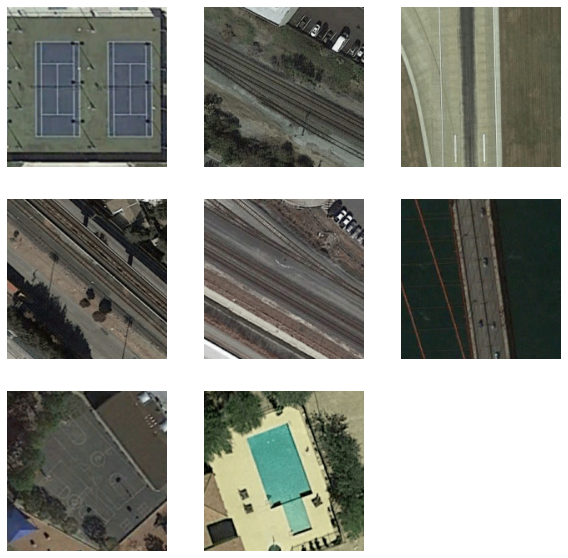

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    #plt.title(train_ds.class_names[labels[i][0].argmax()])
    plt.axis("off")

In [6]:
train_ds.class_names

['basketball_court',
 'bridge',
 'crosswalk',
 'golf_course',
 'oil_well',
 'overpass',
 'railway',
 'runway',
 'swimming_pool',
 'tennis_court']

In [7]:
input_shape = (img_height,img_width,3)

In [8]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [207]:
del model

In [208]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.2),
    
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

In [209]:
def get_cnn_model(input_shape, num_classes, d = 0.2):
  model = Sequential()
  
  model.add(data_augmentation)
  model.add(layers.experimental.preprocessing.Rescaling(1./255))
  #conv
  model.add(Conv2D(16, kernel_size=3,  input_shape = input_shape)) #224
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(MaxPooling2D(pool_size=(2, 2),strides=2, padding='same'))
  model.add(Dropout(d))
  
  #conv
  model.add(Conv2D(32, kernel_size=3)) #112
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(MaxPooling2D(pool_size=(2, 2),strides=2, padding='same'))
  model.add(Dropout(d))

  
  model.add(Conv2D(64, kernel_size=3)) #56
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(MaxPooling2D(pool_size=(2, 2),strides=2, padding='same'))
  model.add(Dropout(d))
  
  #conv
  model.add(Conv2D(128, kernel_size=3,strides = 2, padding = 'same')) #28
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(MaxPooling2D(pool_size=(2, 2),strides=2, padding='same'))
  model.add(Dropout(d))
  
  #conv
  model.add(Conv2D(256, kernel_size=3, padding = 'same')) #14
  model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(MaxPooling2D(pool_size=(2, 2),strides=2, padding='same'))
  #model.add(Dropout(d))


  #model.add(Conv2D(512, kernel_size=2, strides = 1, activation='relu')) #2
  #model.add(BatchNormalization())
  #model.add(LeakyReLU(alpha=0.05))
  #model.add(Dropout(d))

  model.add(Flatten())
  #2 x FC
  model.add(Dense(256,activity_regularizer=keras.regularizers.L1(0.01)))
  #model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(Dropout(0.2))
  model.add(Dense(128))
  #model.add(BatchNormalization())
  model.add(LeakyReLU(alpha=0.05))
  model.add(Dropout(0.2))
  model.add(Dense(num_classes, activation='softmax'))

  #model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
  
  return model


In [210]:
model = get_cnn_model(input_shape, num_classes) #, 0.4
#opt = keras.optimizers.Adam(learning_rate=1e-3)#, decay = 0.95)
# model.compile(optimizer=opt,
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#               metrics=['accuracy'])
model.compile(loss=keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=100, 
                    verbose = 1)

Epoch 1/100
54/54 [==============================] - 5s 48ms/step - loss: 8.0673 - accuracy: 0.1812 - val_loss: 3.5470 - val_accuracy: 0.1200
Epoch 2/100
54/54 [==============================] - 2s 42ms/step - loss: 5.7382 - accuracy: 0.1929 - val_loss: 3.7455 - val_accuracy: 0.0933
Epoch 3/100
54/54 [==============================] - 2s 43ms/step - loss: 4.8360 - accuracy: 0.2776 - val_loss: 3.0707 - val_accuracy: 0.1333
Epoch 4/100
54/54 [==============================] - 2s 42ms/step - loss: 4.0090 - accuracy: 0.3600 - val_loss: 3.1970 - val_accuracy: 0.0933
Epoch 5/100
54/54 [==============================] - 2s 42ms/step - loss: 4.2330 - accuracy: 0.3647 - val_loss: 2.8866 - val_accuracy: 0.1733
Epoch 6/100
54/54 [==============================] - 2s 42ms/step - loss: 3.9979 - accuracy: 0.3929 - val_loss: 2.8861 - val_accuracy: 0.1467
Epoch 7/100
54/54 [==============================] - 2s 42ms/step - loss: 3.4076 - accuracy: 0.5247 - val_loss: 2.4641 - val_accuracy: 0.4000
Epoch 

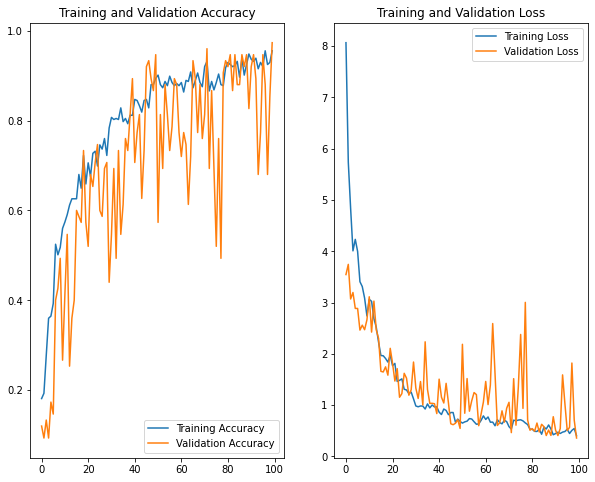

In [211]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [16]:
test_dir = '/content/drive/MyDrive/GNR 638/test'

In [17]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  test_dir,
  labels=None,
  label_mode=None,
  shuffle=False,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 100 files belonging to 1 classes.


In [212]:
predictions = model.predict(test_ds)

In [213]:
del preds

In [214]:
preds = []
for p in tf.nn.softmax(predictions).numpy():
  preds.append(p.argmax()+1)

  

In [215]:
preds = np.asarray(preds)

In [216]:
preds

array([ 5,  3,  3,  5,  4, 10,  8,  4,  2,  2,  1,  1,  5,  6,  8,  9,  1,
        5,  8, 10,  5,  2,  6,  4,  3,  6,  7,  7,  5,  3,  9, 10,  3,  8,
        2,  4,  3,  2,  6,  9,  8, 10,  1,  4,  7,  5, 10,  5,  1,  9,  8,
        8, 10,  6, 10,  4, 10,  3,  7,  2, 10,  6,  9,  2,  4,  4,  8,  9,
        4, 10,  5,  6,  9,  2,  8,  3,  7, 10,  3,  9,  2,  4,  2,  8,  6,
       10,  8,  3,  5,  3,  6,  1,  6,  9,  4,  7,  5,  4, 10,  8])

In [90]:
img_id = []
for i in range(101,201):
  img_id.append(i)

In [91]:
img_id = np.asarray(img_id)

In [218]:

df = pd.DataFrame(columns = ['ImageID', 'LabelID'])

In [219]:
df['ImageID'] = img_id

In [220]:
df['LabelID'] = preds

In [222]:
df.to_csv('final_preds1.csv')

In [96]:
df.head()

,ImageID,LabelID
0,101,5
1,102,8
2,103,3
3,104,5
4,105,2


In [58]:
df.shape

(100, 3)

In [223]:
original = pd.read_csv('/content/drive/MyDrive/GNR 638/original.csv')

c=0
for pr,org in zip(preds,original['LabelID']):
  if pr == org:
    c +=1

print(c)

85


In [224]:
model.save('/content/drive/MyDrive/GNR 638')

INFO:tensorflow:Assets written to: /content/drive/MyDrive/GNR 638/assets


In [225]:
model.save_weights('/content/drive/MyDrive/GNR 638')